# Análise de Sentimentos em Commits (Estilo Escala Likert)

Este notebook foi criado para analisar a proporção de sentimentos **Negativos**, **Neutros** e **Positivos** nas mensagens de commit do repositório, comparando o "Overview Geral" do projeto com a distribuição de sentimentos de cada tipo específico de *test smell*.

Utilizaremos um **Diverging Stacked Bar Chart** (comum para escalas Likert), onde as porcentagens neutras são centralizadas no eixo Y, as porcentagens negativas crescem para a esquerda e as positivas para a direita.

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Conexão e Extração de Dados do Banco de Dados

Nesta etapa, vamos nos conectar ao `resultado.sqlite` e executar duas queries:
1. **Baseline Geral:** Conta os commits com pontuação menor que zero, igual a zero e maior que zero.
2. **Por Test Smell:** Faz a mesma contagem, mas agrupada por `testsmell` utilizando o `hash` do commit.

In [9]:
# Caminho do banco de dados
db_path = '/home/tassio/.dnose/results/resultado.sqlite'

# Conectando ao banco de dados
conn = sqlite3.connect(db_path)

# 1. Buscando o Overview Geral (Baseline)
query_geral = '''
SELECT 
    SUM(CASE WHEN score < 0 THEN 1 ELSE 0 END) as Negative,
    SUM(CASE WHEN score = 0 THEN 1 ELSE 0 END) as Neutral,
    SUM(CASE WHEN score > 0 THEN 1 ELSE 0 END) as Positive
FROM commit_sentiments
WHERE score IS NOT NULL
'''
df_geral = pd.read_sql_query(query_geral, conn)
df_geral['Category'] = 'Overview Geral (Baseline)'

# 2. Buscando as contagens por tipo de Test Smell
# Utilizamos COUNT(DISTINCT c.hash) para não contar o mesmo commit mais de uma vez caso haja múltiplos smells do mesmo tipo.
query_smells = '''
SELECT 
    t.testsmell as Category,
    COUNT(DISTINCT CASE WHEN c.score < 0 THEN c.hash END) as Negative,
    COUNT(DISTINCT CASE WHEN c.score = 0 THEN c.hash END) as Neutral,
    COUNT(DISTINCT CASE WHEN c.score > 0 THEN c.hash END) as Positive
FROM commit_sentiments c
JOIN testsmells t ON c.hash = t."commit"
WHERE c.score IS NOT NULL
GROUP BY t.testsmell
'''
df_smells = pd.read_sql_query(query_smells, conn)

# Fechando a conexão
conn.close()

# Visualizando as primeiras linhas do dataframe resultante
df_smells.head()

,Category,Negative,Neutral,Positive
0,Assertion Roulette,84,2096,142
1,Conditional Test Logic,33,618,40
2,Duplicate Assert,84,2148,139
3,Empty Test,14,318,42
4,Exception Handling,15,319,23


## 2. Processamento e Cálculo das Porcentagens

Para gerar o gráfico de barras divergentes, precisamos transformar as contagens absolutas em porcentagens (0% a 100%) para cada categoria. Dessa forma, conseguimos comparar a proporção de negatividade/positividade independente da frequência do test smell.

In [10]:
# Concatenando os dataframes do overview geral e dos test smells
df = pd.concat([df_geral, df_smells], ignore_index=True)

# Calculando o total e as porcentagens para cada linha
df['Total'] = df['Negative'] + df['Neutral'] + df['Positive']
df['Neg_Pct'] = (df['Negative'] / df['Total']) * 100
df['Neu_Pct'] = (df['Neutral'] / df['Total']) * 100
df['Pos_Pct'] = (df['Positive'] / df['Total']) * 100

# Ordenando o dataframe:
# Queremos fixar o 'Overview Geral' no topo do gráfico.
# Para os demais test smells, vamos ordená-los pela porcentagem de sentimento Negativo (ordem crescente).
df_baseline = df[df['Category'] == 'Overview Geral (Baseline)']
df_rest = df[df['Category'] != 'Overview Geral (Baseline)'].sort_values('Neg_Pct', ascending=True)
df_final = pd.concat([df_rest, df_baseline], ignore_index=True)

df_final

,Negative,Neutral,Positive,Category,Total,Neg_Pct,Neu_Pct,Pos_Pct
0,2,53,9,Ignored Test,64,3.125000,82.812500,14.062500
1,84,2148,139,Duplicate Assert,2371,3.542809,90.594686,5.862505
2,84,2096,142,Assertion Roulette,2322,3.617571,90.267011,6.115418
3,43,1047,91,Unknown Test,1181,3.640982,88.653683,7.705334
4,14,318,42,Empty Test,374,3.743316,85.026738,11.229947
5,8,178,13,Sleepy Fixture,199,4.020101,89.447236,6.532663
6,61,1355,87,Magic Number,1503,4.058550,90.153027,5.788423
7,12,252,22,Resource Optimism,286,4.195804,88.111888,7.692308
8,15,319,23,Exception Handling,357,4.201681,89.355742,6.442577
9,19,377,25,Sensitive Equality,421,4.513064,89.548694,5.938242


## 3. Geração do Gráfico Likert (Diverging Stacked Bar Chart)

A lógica matemática do gráfico é a seguinte:
- Para que a barra neutra fique no meio exato do gráfico (no 0 do eixo X), dividimos a barra neutra pela metade.
- A **barra Neutra** começará no eixo `X = - (Neu_Pct / 2)`.
- A **barra Negativa** começará à esquerda da neutra, em `X = - (Neg_Pct + Neu_Pct / 2)`.
- A **barra Positiva** começará à direita da neutra, em `X = (Neu_Pct / 2)`.

As cores seguirão um padrão de mapa de calor semáforo: Vermelho (Negativo), Cinza (Neutro), e Azul (Positivo).

/tmp/ipykernel_140167/2574887904.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(tick))}%' for tick in ticks])


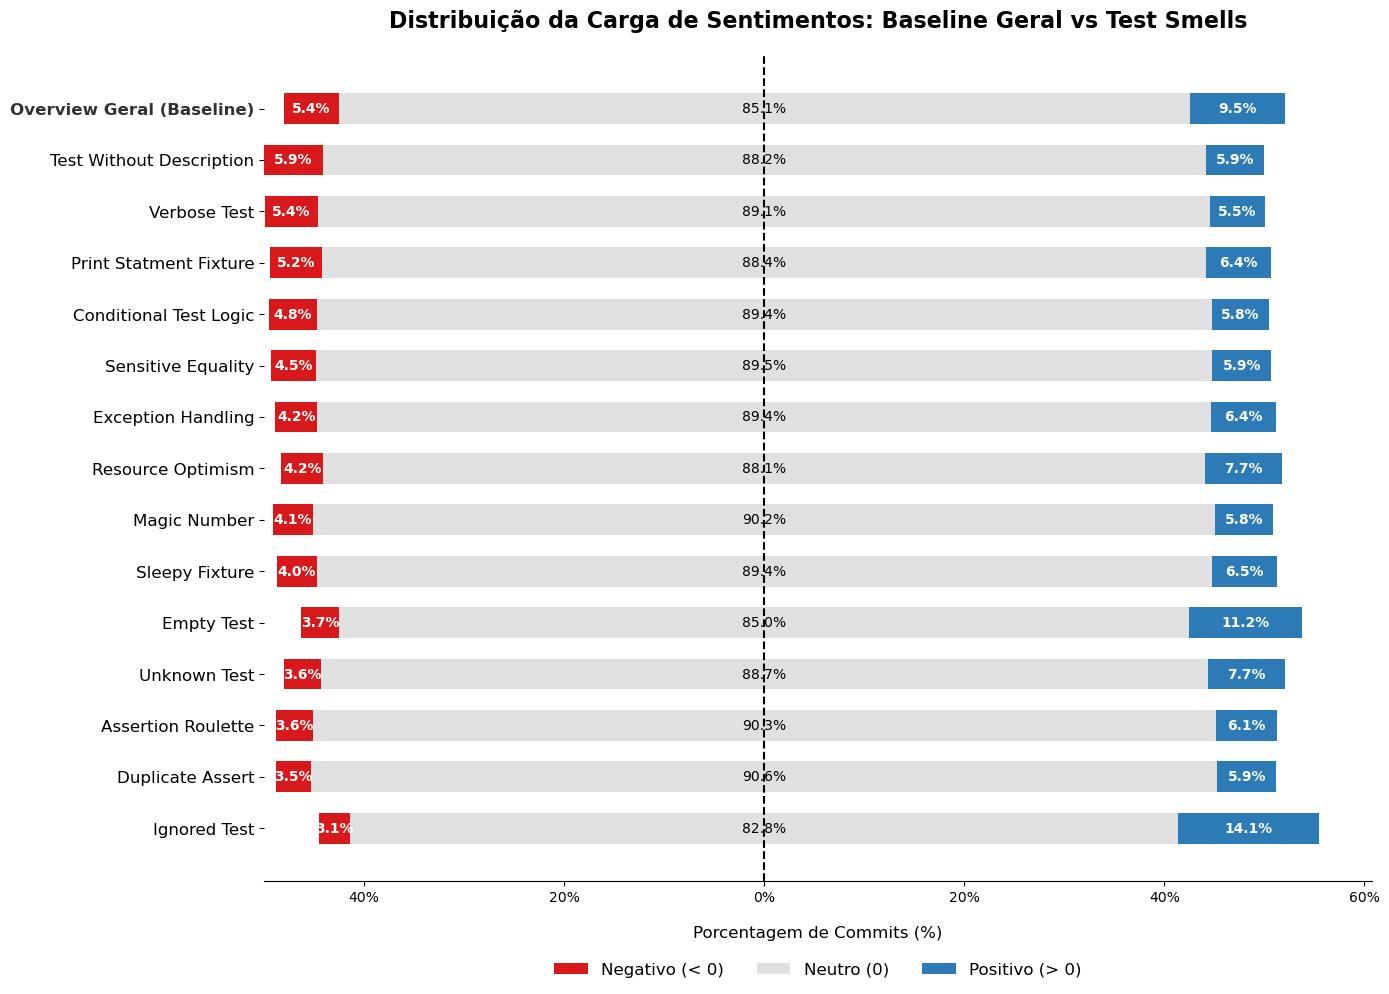

Gráfico gerado e salvo em: /home/tassio/Development/pessoal/jserd2026/dataset/sentiment_likert_chart.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 10))

categories = df_final['Category']
y_pos = np.arange(len(categories))

# Calculando os pontos de início no eixo X para as 3 categorias
starts_neg = -(df_final['Neg_Pct'] + df_final['Neu_Pct'] / 2)
starts_neu = -(df_final['Neu_Pct'] / 2)
starts_pos = (df_final['Neu_Pct'] / 2)

# Definição das cores
color_neg = '#d7191c' # Vermelho escuro
color_neu = '#e0e0e0' # Cinza claro
color_pos = '#2c7bb6' # Azul escuro

# Plotando as barras com matplotlib
ax.barh(y_pos, df_final['Neg_Pct'], left=starts_neg, height=0.6, color=color_neg, label='Negativo (< 0)', edgecolor='none')
ax.barh(y_pos, df_final['Neu_Pct'], left=starts_neu, height=0.6, color=color_neu, label='Neutro (0)', edgecolor='none')
ax.barh(y_pos, df_final['Pos_Pct'], left=starts_pos, height=0.6, color=color_pos, label='Positivo (> 0)', edgecolor='none')

# Adicionando os textos com a porcentagem exata dentro das barras para facilitar a leitura
for i in range(len(y_pos)):
    neg_val = df_final['Neg_Pct'].iloc[i]
    neu_val = df_final['Neu_Pct'].iloc[i]
    pos_val = df_final['Pos_Pct'].iloc[i]
    
    # Texto Negativo (escreve apenas se tiver espaço visual, ex: > 2%)
    if neg_val > 2:
        ax.text(starts_neg[i] + neg_val/2, y_pos[i], f'{neg_val:.1f}%', va='center', ha='center', color='white', fontweight='bold')
    
    # Texto Neutro
    if neu_val > 5:
        ax.text(starts_neu[i] + neu_val/2, y_pos[i], f'{neu_val:.1f}%', va='center', ha='center', color='black')
        
    # Texto Positivo
    if pos_val > 2:
        ax.text(starts_pos[i] + pos_val/2, y_pos[i], f'{pos_val:.1f}%', va='center', ha='center', color='white', fontweight='bold')

# --- Estilização do Gráfico ---

# Aplicando as categorias no eixo Y
ax.set_yticks(y_pos)
ax.set_yticklabels(categories, fontsize=12)

# Configurando o eixo X
ax.set_xlabel('Porcentagem de Commits (%)', fontsize=12, labelpad=15)
ax.set_title('Distribuição da Carga de Sentimentos: Baseline Geral vs Test Smells', fontsize=16, pad=20, fontweight='bold')

# Destacando a fonte da primeira linha (Overview Geral)
ax.get_yticklabels()[-1].set_fontweight("bold")
ax.get_yticklabels()[-1].set_color("#333333")

# Adicionando uma linha vertical preta marcando o centro do neutro (eixo 0)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')

# Formatando as marcações numéricas do eixo X para mostrarem valores absolutos (Ex: 20%, 40% em vez de -20, -40)
ticks = ax.get_xticks()
ax.set_xticklabels([f'{abs(int(tick))}%' for tick in ticks])

# Retirando bordas (spines) de cima, baixo, esquerda e direita para um visual mais limpo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Adicionando a Legenda na parte inferior do gráfico
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=12, frameon=False)

plt.tight_layout()

# Salvando o gráfico localmente com alta resolução
output_path = '/home/tassio/Development/pessoal/jserd2026/dataset/sentiment_likert_chart.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()
print(f'Gráfico gerado e salvo em: {output_path}')